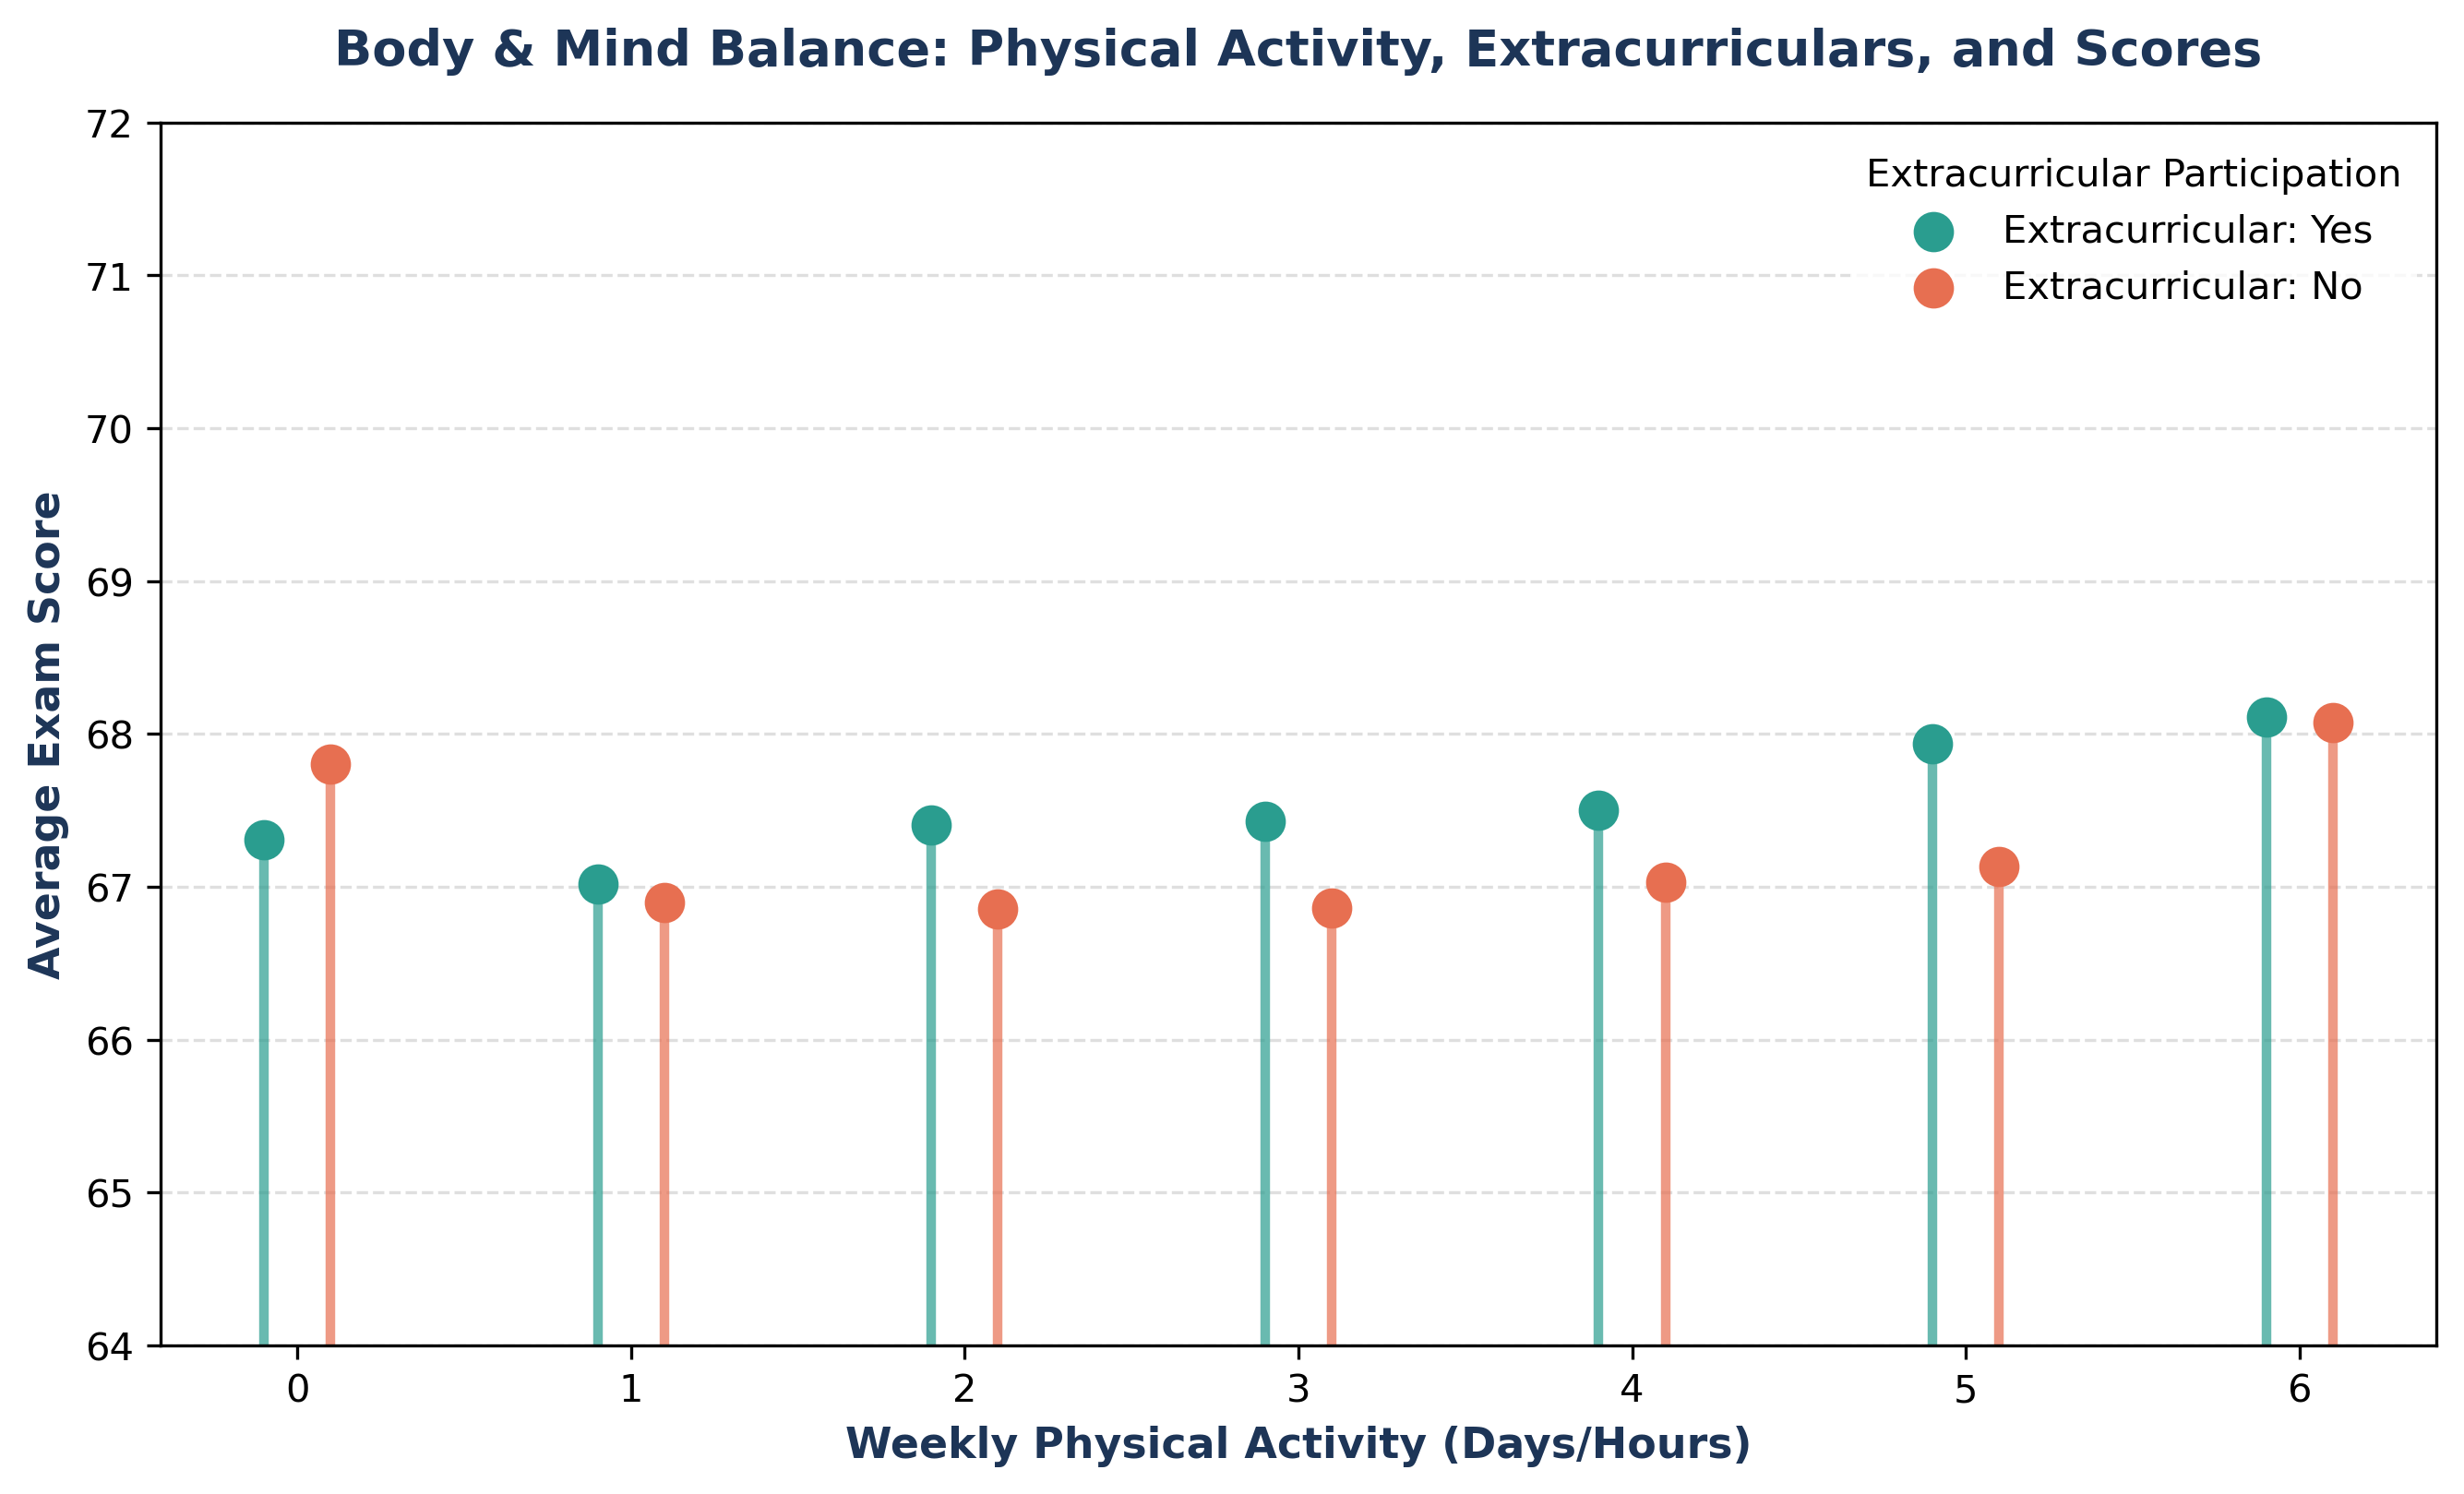

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('StudentPerformanceFactors.csv')

grouped_activity = df.groupby(['Physical_Activity', 'Extracurricular_Activities'])['Exam_Score'].mean().reset_index()

palette = {'Yes': '#2A9D8F', 'No': '#E76F51'}

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)

for activity_status in ['Yes', 'No']:
    sub_df = grouped_activity[grouped_activity['Extracurricular_Activities'] == activity_status]
    offset = -0.1 if activity_status == 'Yes' else 0.1
    ax.vlines(x=sub_df['Physical_Activity'] + offset, ymin=60, ymax=sub_df['Exam_Score'], 
              color=palette[activity_status], alpha=0.7, linewidth=2.5)
    ax.scatter(sub_df['Physical_Activity'] + offset, sub_df['Exam_Score'], 
               color=palette[activity_status], s=90, label=f'Extracurricular: {activity_status}', zorder=3)

ax.set_title("Body & Mind Balance: Physical Activity, Extracurriculars, and Scores", fontsize=13, fontweight='bold', pad=15, color='#1D3557')
ax.set_xlabel("Weekly Physical Activity (Days/Hours)", fontsize=11, fontweight='bold', color='#1D3557')
ax.set_ylabel("Average Exam Score", fontsize=11, fontweight='bold', color='#1D3557')
ax.set_ylim(64, 72)

ax.legend(title="Extracurricular Participation", frameon=True, facecolor='white', edgecolor='none')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()